

### 1) Import Pandas


In [ ]:
# your code here
import pandas as pd

### 2) Import the dataset and  Assign it to a variable called users and use the 'user_id' as index

Use the following dataset
https://raw.githubusercontent.com/justmarkham/DAT8/master/data/u.user


In [ ]:
# your code here
users = pd.read_csv(
    "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/u.user", sep="|"
)
users.set_index("user_id", inplace=True)

### 3) Display the first 25 entries

In [ ]:
# your code here
users.head(25)

,age,gender,occupation,zip_code
user_id,,,,
1,24,M,technician,85711
2,53,F,other,94043
3,23,M,writer,32067
4,24,M,technician,43537
5,33,F,other,15213
6,42,M,executive,98101
7,57,M,administrator,91344
8,36,M,administrator,05201
9,29,M,student,01002


### 4) Display the last 10 entries

In [ ]:
# your code here
users.tail(10)

,age,gender,occupation,zip_code
user_id,,,,
934,61,M,engineer,22902
935,42,M,doctor,66221
936,24,M,other,32789
937,48,M,educator,98072
938,38,F,technician,55038
939,26,F,student,33319
940,32,M,administrator,02215
941,20,M,student,97229
942,48,F,librarian,78209


### 5) What is the number of observations in the dataset?

In [ ]:
# your code here
len(users)

943

### 6) What is the number of columns in the dataset, also print the name of all the columns?

In [ ]:
# your code here
print(len(users.columns), "columns : ", users.columns)

4 columns :  Index(['age', 'gender', 'occupation', 'zip_code'], dtype='str')


### 7) What is the data type of each column?

In [ ]:
# your code here
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 943 entries, 1 to 943
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         943 non-null    int64
 1   gender      943 non-null    str  
 2   occupation  943 non-null    str  
 3   zip_code    943 non-null    str  
dtypes: int64(1), str(3)
memory usage: 29.6 KB


### 8) Print only the occupation column

In [ ]:
# your code here
users.occupation

user_id
1         technician
2              other
3             writer
4         technician
5              other
           ...      
939          student
940    administrator
941          student
942        librarian
943          student
Name: occupation, Length: 943, dtype: str

### 9) How many different occupations are in this dataset?


In [ ]:
# your code here
users.occupation.nunique()

21

### 10) What is the most frequent occupation?

In [ ]:
# your code here
users["occupation"].value_counts().index[0]

'student'

### 11) Summarize the DataFrame.

In [ ]:
# your code here
users.describe(include="all")

,age,gender,occupation,zip_code
count,943.000000,943,943,943
unique,NaN,2,21,795
top,NaN,M,student,55414
freq,NaN,670,196,9
mean,34.051962,NaN,NaN,NaN
std,12.192740,NaN,NaN,NaN
min,7.000000,NaN,NaN,NaN
25%,25.000000,NaN,NaN,NaN
50%,31.000000,NaN,NaN,NaN
75%,43.000000,NaN,NaN,NaN


### 12) Summarize only the occupation column

In [ ]:
# your code here
users["occupation"].describe()

count         943
unique         21
top       student
freq          196
Name: occupation, dtype: object

### 13) What is the mean age of users?

In [ ]:
# your code here
print(users["age"].mean())

34.05196182396607


### 14) What is the age with least occurrence?

In [ ]:
# your code here
age_counts = users["age"].value_counts()
least_occurrence_ages = age_counts[age_counts == age_counts.min()].index

users[users["age"].isin(least_occurrence_ages)]["age"]

user_id
30      7
211    66
289    11
471    10
481    73
Name: age, dtype: int64

### 15) What is the zip code with most occurrence?

In [ ]:
# your code here
users["zip_code"].value_counts().index[0]

'55414'

### 16) Which profession has youngest people(apart from student)? Show the trend of mean age of people with profession as the seperating factor.

profession with youngest people after students :  none


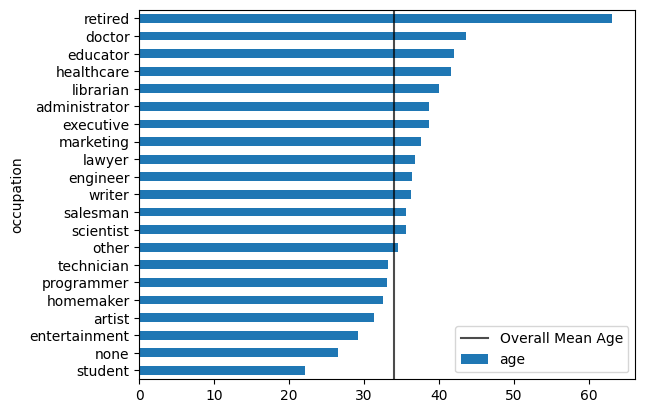

In [48]:
# your code here
import matplotlib.pyplot as plt

print(
    "profession with youngest people after students : ",
    users[users["occupation"] != "student"]
    .sort_values(by=["age"])["occupation"]
    .iloc[0],
)

users.groupby(by=["occupation"])["age"].mean().sort_values().plot(
    kind="barh", layout=(12, 4)
)
plt.axvline(users["age"].mean(), color="black", label="Overall Mean Age",alpha=0.7)

plt.legend()
plt.show()